# Introduction to Machine Learning Lab - Early Medical Diagnosis System

**Project:** Diabetes Risk Prediction  
**Course:** Introduction to Machine Learning Lab  
**Dataset:** [Diabetes prediction dataset](https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset) (Kaggle, uploaded by Mohammed Mustafa), fetched programmatically with the official Kaggle API.

## Contents

| Section | Content |
|---|---|
| **0** | Why these models - the candidate pool, and why four were carried forward |
| **1** | Data set |
| **2** | Data exploration and cleaning |
| **3** | Data wrangling |
| **4** | Feature selection |
| **5** | Model deployment |
| **6** | Performance metrics / confusion matrix |
| **7** | Result |
| **8** | Conclusions and limitations |

## How to read this notebook

The headline finding is not the best accuracy. It is that **accuracy is the wrong
metric for this problem**. The dataset is 91.2% negative, so a model that answers
"no diabetes" for every patient already scores 0.9118 accuracy while catching none
of them. The models below deliberately trade accuracy for recall, and the
Precision-Recall curve is the figure that actually shows the trade-off.

## 0. Setup

All reusable logic lives in the `src/` package, so the same code runs here and
from `python run_pipeline.py`.

In [1]:
import sys
from pathlib import Path


def find_project_root() -> Path:
    """Locate the project root, i.e. the folder that contains ``src/``.

    Works unchanged on a local machine and on Google Colab: locally we
    walk up from the working directory, and on Colab we additionally
    search ``/content``, where uploaded files are placed.
    """
    candidates = [Path.cwd(), *Path.cwd().parents]
    content = Path("/content")
    if content.is_dir():
        candidates += [content, *sorted(p for p in content.iterdir() if p.is_dir())]
    for candidate in candidates:
        if (candidate / "src").is_dir():
            return candidate
    raise FileNotFoundError(
        "No folder containing 'src/' was found. On Google Colab, upload "
        "the project archive and unzip it before running this cell."
    )


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: P:\My projects\ML lab project


In [2]:
# Installs only what is missing, so this is a no-op on a machine that
# already has the dependencies (e.g. after `pip install -r requirements.txt`).
import importlib.util
import subprocess
import sys

REQUIRED = {
    "pandas": "pandas",
    "numpy": "numpy",
    "sklearn": "scikit-learn",
    "xgboost": "xgboost",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
}
missing = [pkg for mod, pkg in REQUIRED.items()
           if importlib.util.find_spec(mod) is None]
if missing:
    print(f"Installing: {', '.join(missing)}")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing],
                   check=True)
else:
    print("All required packages are already installed.")

All required packages are already installed.


In [3]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

import pandas as pd
from sklearn.feature_selection import f_classif
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

from src import plots
from src.data import (
    RANDOM_STATE, TARGET,
    build_preprocessor, category_breakdown, class_balance, data_quality_report,
    drop_duplicates, duplicate_report, load_data, majority_baseline, make_splits,
    missing_value_report, summary_statistics,
)
from src.evaluation import (
    baseline_evaluation, baseline_reference_line, evaluate_pipeline,
    final_result_table, metrics_table,
)
from src.fetch_data import KAGGLE_URL, fetch
from src.models import (
    _cv, feature_importance, get_specs, imbalance_ratio, overfitting_check,
    stratified_subsample, tune_model,
)

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

print(f"pandas           {pd.__version__}")
import sklearn
print(f"scikit-learn     {sklearn.__version__}")
print(f"random_state     {RANDOM_STATE}")
print(f"source           {KAGGLE_URL}")

pandas           3.0.6
scikit-learn     1.9.1
random_state     42
source           https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset


## 0. Why these models

The candidate pool is **Linear Regression, Decision Tree, SVM, Logistic Regression,
KNN and XGBoost**. Each is assessed against the problem - binary classification on
structured tabular clinical data - *before* any pipeline is built, so the final
shortlist is a decision rather than an arbitrary pick.

| Candidate | Include? | Reasoning |
|---|---|---|
| **Linear Regression** | Excluded | Designed for continuous targets, not class labels. On a 0/1 diagnosis outcome it violates its own assumptions (unbounded output, Gaussian errors) and yields no probabilistic class interpretation. Wrong tool for classification. |
| **Logistic Regression (Log St)** | **Included** | The natural discriminative baseline for binary classification. Emits calibrated probabilities, its coefficients map directly onto clinical risk factors, and it is cheap. It is the right first assumption for clinical data that is roughly linearly separable. |
| **Decision Tree (DT)** | **Included** | Captures non-linear relationships and feature interactions (e.g. "high glucose AND high BMI") without needing scaling. Its rule structure is directly readable, which matters when a clinician must know *why* a patient was flagged. Also the natural stepping stone to the XGBoost ensemble. |
| **SVM** | **Included** | Clinical data is rarely linearly separable in raw feature space. The RBF kernel maps features into a higher-dimensional space to find a cleaner boundary, and works well on small-to-medium tabular medical datasets. |
| **KNN** | Excluded | Vulnerable to the curse of dimensionality and to feature scaling, slow at inference on large data, and it yields no model artifact - it simply memorises the training set. That leaves nothing interpretable to show a clinician, so it does not serve a decision-support narrative. |
| **XGBoost** | **Included** | A gradient-boosted ensemble that is typically the strongest performer on structured tabular data. Handles non-linearity, feature interactions and missing values well, and supplies feature-importance scores that restore some interpretability. Carried as the performance benchmark. |

**Shortlist: Log St, DT, SVM, XGBoost.** The selection spans simple and interpretable
(Log St) -> interpretable and non-linear (DT) -> non-linear and kernel-based (SVM) ->
high-performance ensemble (XGBoost), so the four results are genuinely comparable
rather than four arbitrary models.

Section 5 confirms this choice empirically - and one result is worth previewing here,
because it is only visible once the models have actually been run:

| Model | Test ROC-AUC | Change vs. the simpler model above |
|---|---|---|
| Logistic Regression | 0.9639 | - (baseline) |
| SVM (RBF) | 0.9619 | **-0.0020** |
| Decision Tree | 0.9748 | +0.0109 |
| XGBoost | **0.9799** | +0.0051 |

**The RBF kernel performed slightly worse than plain logistic regression.** The
decision boundary in this dataset is close to linear, so mapping it into a
higher-dimensional space bought nothing and cost a little. Non-linearity is real,
but it is worth about **+0.011** ROC-AUC, and the boosted ensemble adds only
**+0.005** more on top. That single fact shapes the recommendation in section 7:
a large model earns very little here.

## 1. Data set

The primary dataset is the **Kaggle "Diabetes prediction dataset"** (Mohammed
Mustafa), chosen for three reasons: it mixes numeric and categorical clinical
features, its target is binary, and at 100,000 records it is large enough that the
train/validation/test split leaves enough positive cases for model differences to
be meaningful.

| Property | Value |
|---|---|
| Source | Kaggle, `iammustafatz/diabetes-prediction-dataset` |
| Raw rows | 100,000 |
| Columns | 9 (8 features + 1 target) |
| Numeric features | 6 - `age`, `hypertension`, `heart_disease`, `bmi`, `HbA1c_level`, `blood_glucose_level` |
| Categorical features | 2 - `gender`, `smoking_history` |
| Target | `diabetes` (1 = positive, 0 = negative) |
| Class balance | 91,500 negative / 8,500 positive (8.5% positive) |

`fetch()` downloads through the official Kaggle API on first run and validates the
file on every run, then reuses the local copy. Validation is strict on purpose: a
truncated download or a changed schema should fail loudly rather than silently
produce wrong numbers.

**Kaggle credentials are optional.** `fetch()` downloads through the Kaggle
API only when `data/diabetes_prediction_dataset.csv` is absent. Because the
archive you upload already contains that file, this step re-reads and re-validates
it locally and never touches the network — so no `credentials.json` is needed.

In [4]:
raw = fetch()
raw.shape

Using existing data\diabetes_prediction_dataset.csv (100,000 rows)


(100000, 9)

In [5]:
class_balance(raw)

,Diagnosis,Count,Percent,Ratio
0,Negative (no diabetes),91500,91.5,10.764706
1,Positive (diabetes),8500,8.5,10.764706


## 2. Data exploration and cleaning

### 2.1 Summary statistics

In [6]:
summary_statistics(raw).round(2)

,count,mean,std,min,25%,50%,75%,max
age,100000.0,41.89,22.52,0.08,24.00,43.00,60.00,80.00
hypertension,100000.0,0.07,0.26,0.00,0.00,0.00,0.00,1.00
heart_disease,100000.0,0.04,0.19,0.00,0.00,0.00,0.00,1.00
bmi,100000.0,27.32,6.64,10.01,23.63,27.32,29.58,95.69
HbA1c_level,100000.0,5.53,1.07,3.50,4.80,5.80,6.20,9.00
blood_glucose_level,100000.0,138.06,40.71,80.00,100.00,140.00,159.00,300.00


### 2.2 Missing data

`isnull()` reports **zero** missing values. That is misleading: 35.8% of rows hide
their missingness inside `smoking_history` as the string `"No Info"`. A pipeline
that trusted `isnull()` alone would treat those rows as complete.

In [7]:
missing_value_report(raw)

,Feature,NaN cells,'No Info' sentinel,Total missing
0,gender,0,0,0
1,age,0,0,0
2,hypertension,0,0,0
3,heart_disease,0,0,0
4,smoking_history,0,35816,35816
5,bmi,0,0,0
6,HbA1c_level,0,0,0
7,blood_glucose_level,0,0,0
8,diabetes,0,0,0


### 2.3 Duplicate records

3,854 rows (3.85%) are exact duplicates. Critically, only **one** group of duplicate
records disagrees on the label, so removing them discards no information.

In [8]:
duplicate_report(raw)

,Check,Count
0,Full-row duplicates,3854
1,Duplicates ignoring target,3945
2,Rows in a duplicate group,6939
3,Groups with conflicting labels,1


In [9]:
df = drop_duplicates(raw)
removed = len(raw) - len(df)
print(f"Removed {removed:,} duplicate rows -> {len(df):,} rows")
print(f"Positive rate: {100 * df[TARGET].mean():.2f}% (was {100 * raw[TARGET].mean():.2f}%)")
df.head()

Removed 3,854 duplicate rows -> 96,146 rows
Positive rate: 8.82% (was 8.50%)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


### 2.4 The `"No Info"` decision

Whether the 35,816 `"No Info"` rows are *random* or *systematic* missingness decides
how they should be handled, so this is measured rather than assumed.

In [10]:
category_breakdown(raw).query("Feature == 'smoking_history'")

,Feature,Value,Count,Diabetes %
6,smoking_history,former,9352,17.00
5,smoking_history,ever,4004,11.79
8,smoking_history,not current,6447,10.70
4,smoking_history,current,9286,10.21
7,smoking_history,never,35095,9.53
3,smoking_history,No Info,35816,4.06


`"No Info"` has a **4.06%** diabetes rate against **9.53% to 17.00%** for every genuine
smoking category. Missingness that correlates this strongly with the target is
systematic, not random, so it is **kept as its own category**. Imputing it would
discard real signal and would tell a doctor that these 35,816 patients never smoked.

The same table shows `gender == "Other"` (18 rows, 0% positive) and that
`hypertension` and `heart_disease` more than quadruple the diabetes rate when present.

In [11]:
category_breakdown(raw).query("Feature != 'smoking_history'")

,Feature,Value,Count,Diabetes %
1,gender,Male,41430,9.75
0,gender,Female,58552,7.62
2,gender,Other,18,0.00
12,heart_disease,1,3942,32.14
11,heart_disease,0,96058,7.53
10,hypertension,1,7485,27.90
9,hypertension,0,92515,6.93


### 2.5 Physiologically impossible values

These are **reported, not corrected**. A minimum age of 0.08 years is not a data-entry
error that can be repaired; it is evidence that a synthetic generator produced noise.
(The approved plan proposed treating such values as missing - the reason for the
deviation is recorded in section 8.)

In [12]:
data_quality_report(raw)

,Check,Rows,Percent of data
0,age below 18,17219,17.22
1,age below 1 year,911,0.91
2,age above 75,8387,8.39
3,bmi below 15,1476,1.48
4,bmi above 60,115,0.12
5,bmi == 0,0,0.00
6,HbA1c above 10,0,0.00
7,blood glucose below 70,0,0.00
8,gender == 'Other',18,0.02


In [13]:
child = raw["age"] < 18
print(f"Patients under 18      : {int(child.sum()):,} "
      f"({100 * child.mean():.1f}% of the data)")
print(f"  ... of whom under 1 yr : {int((raw['age'] < 1).sum()):,}")
print(f"Positives among them    : {int(raw.loc[child, TARGET].sum()):,} "
      f"({100 * raw.loc[child, TARGET].mean():.2f}% vs "
      f"{100 * raw[TARGET].mean():.2f}% overall)")

print("\nSo in this dataset being a child is nearly equivalent to being "
      "negative.\nAge ranks 3rd in feature importance partly for that reason, "
      "not only because age is clinically real.")

Patients under 18      : 17,219 (17.2% of the data)
  ... of whom under 1 yr : 911
Positives among them    : 82 (0.48% vs 8.50% overall)

So in this dataset being a child is nearly equivalent to being negative.
Age ranks 3rd in feature importance partly for that reason, not only because age is clinically real.


### 2.6 Visual exploration

Histograms, boxplots, the class split, categorical rates, the correlation matrix and
the missingness sentinel.

(array([[<Axes: title={'center': 'age'}, xlabel='diabetes (0 = no, 1 = yes)', ylabel='age'>,
         <Axes: title={'center': 'hypertension'}, xlabel='diabetes (0 = no, 1 = yes)', ylabel='hypertension'>,
         <Axes: title={'center': 'heart_disease'}, xlabel='diabetes (0 = no, 1 = yes)', ylabel='heart_disease'>],
        [<Axes: title={'center': 'bmi'}, xlabel='diabetes (0 = no, 1 = yes)', ylabel='bmi'>,
         <Axes: title={'center': 'HbA1c_level'}, xlabel='diabetes (0 = no, 1 = yes)', ylabel='HbA1c_level'>,
         <Axes: title={'center': 'blood_glucose_level'}, xlabel='diabetes (0 = no, 1 = yes)', ylabel='blood_glucose_level'>]],
       dtype=object),
 WindowsPath('P:/My projects/ML lab project/figures/01b_numeric_boxplots.png'))

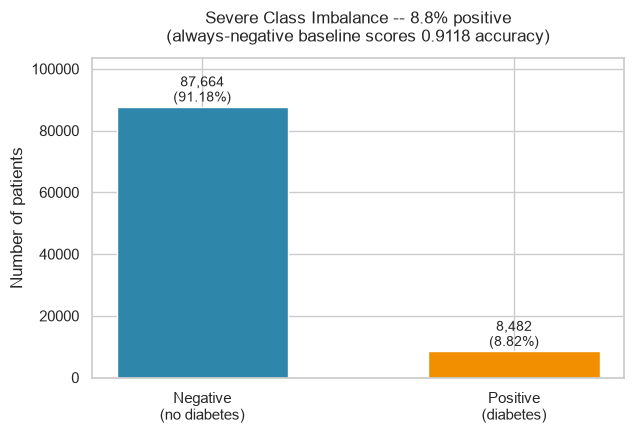

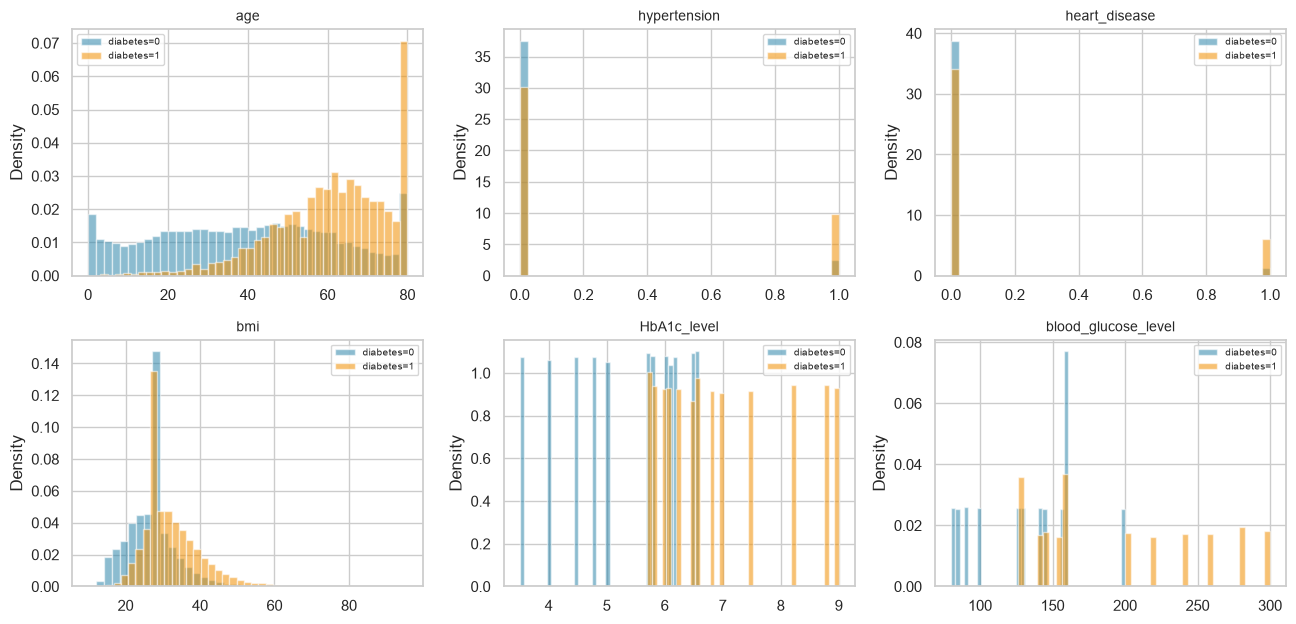

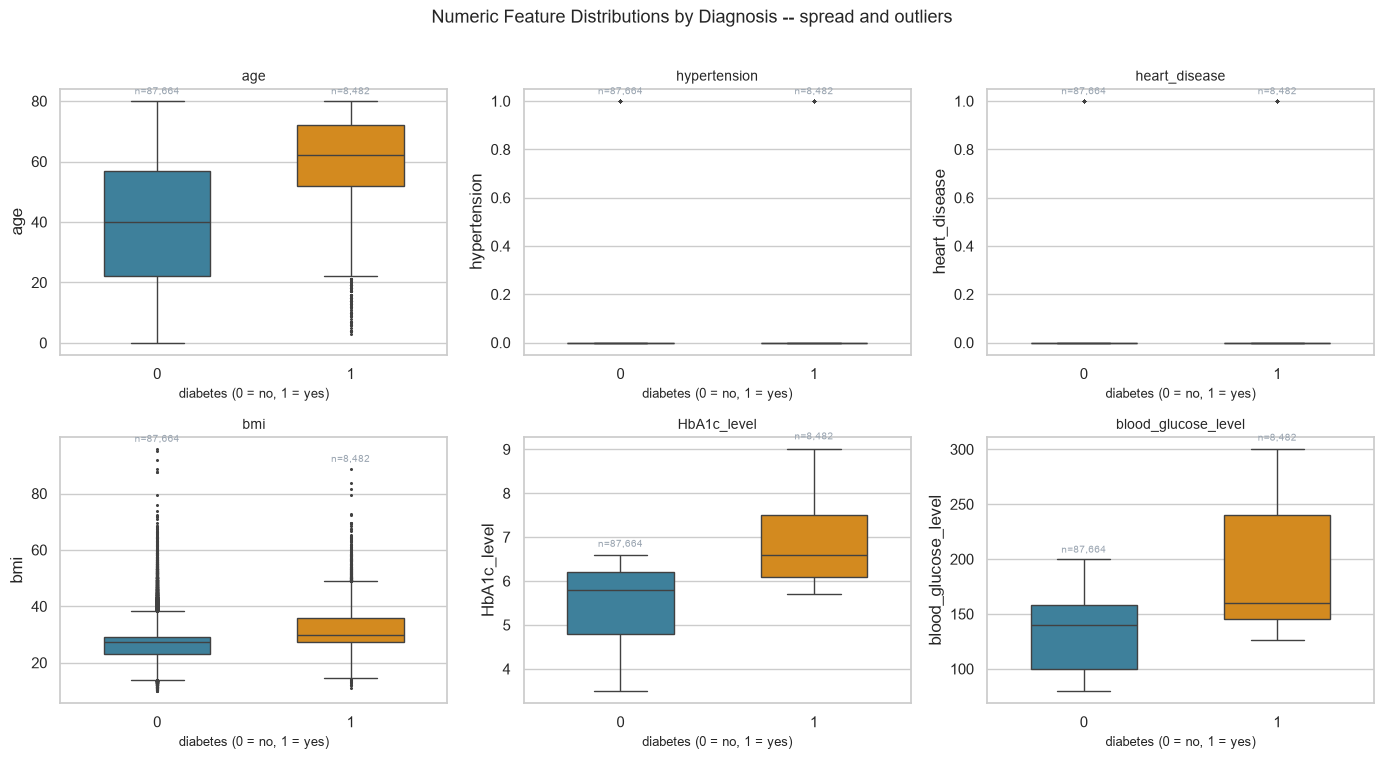

In [14]:
plots.plot_class_balance(df)
plots.plot_numeric_distributions(df)
plots.plot_numeric_boxplots(df)

(<Axes: title={'center': "Missing Data: isnull() reports 0, but 35.8% of rows are\nencoded as the string 'No Info' in smoking_history"}, ylabel='Rows'>,
 WindowsPath('P:/My projects/ML lab project/figures/05_missingness_sentinel.png'))

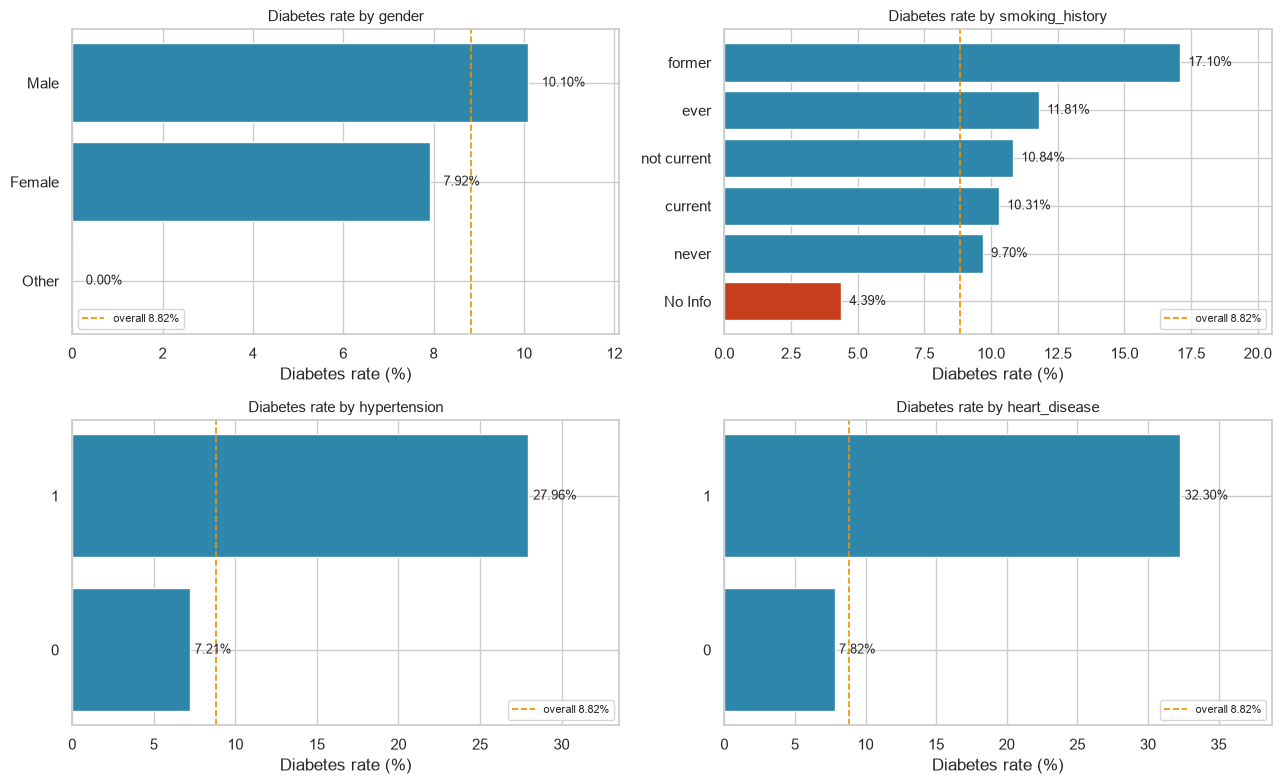

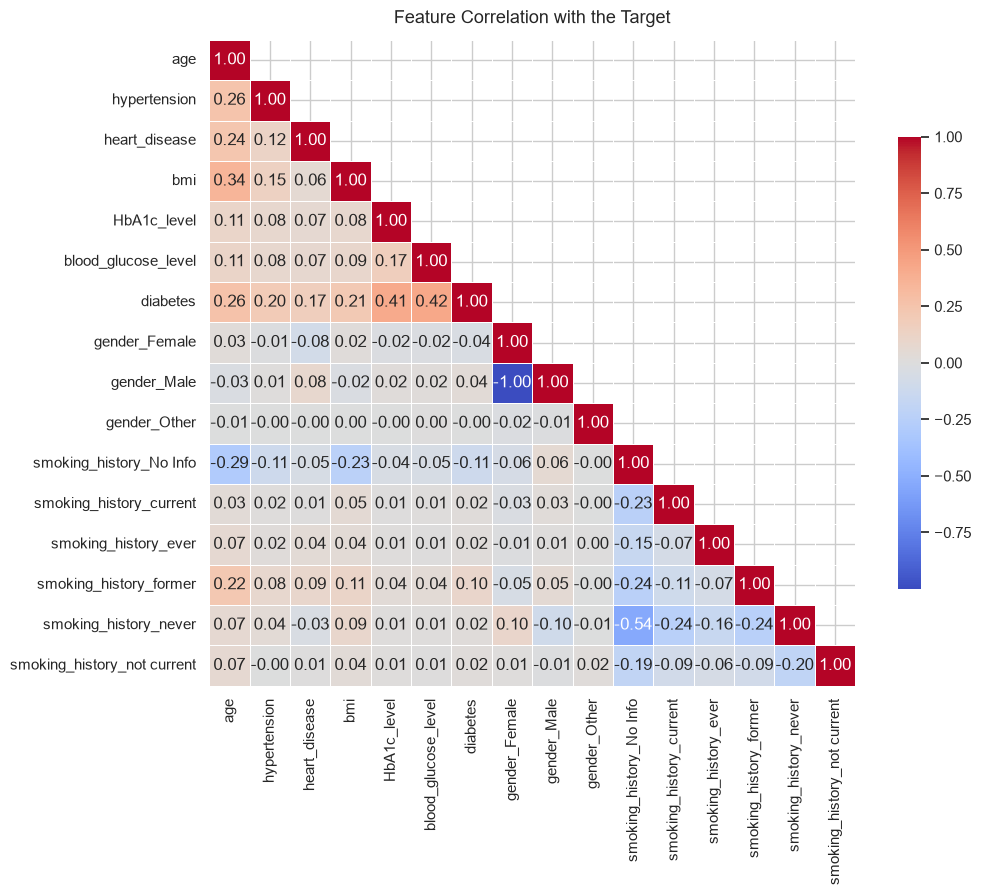

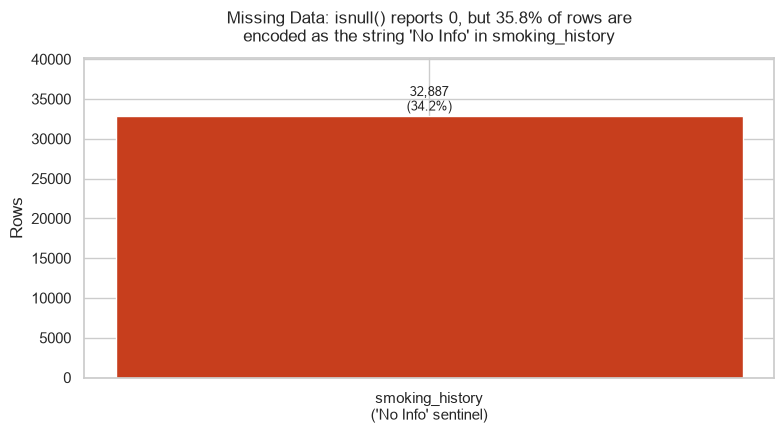

In [15]:
plots.plot_category_diabetes_rates(df)
plots.plot_correlation_heatmap(df)
plots.plot_missingness(df)

`blood_glucose_level` (r ~ 0.42) and `HbA1c_level` (r ~ 0.40) dominate. The
categorical correlations are much weaker, and the heatmap shows that a 0/1 flag such
as `hypertension` is not an independent copy of the target.

## 3. Data wrangling

### 3.1 Imputation, encoding and scaling

Two paths, because numeric and categorical features need different treatment. Every
step is a fitted estimator inside the `ColumnTransformer`, so fitting on the training
split cannot leak validation or test statistics backwards.

| Path | Steps | Why |
|---|---|---|
| Numeric | median imputation -> `StandardScaler` | `bmi` and `blood_glucose_level` are right-skewed, so the median resists outliers better than the mean. Scaling is required by Logistic Regression and SVM. |
| Categorical | most-frequent imputation -> one-hot | Keeps categories discrete and avoids imposing a false order on labels. One-hot columns are **not** scaled, since a 0/1 indicator belongs on its natural scale. |

The median imputers never actually fire here - the dataset has no NaN cells - but
they are kept so the pipeline is robust if the data changes.

In [16]:
pre = build_preprocessor()
Xt = pre.fit_transform(df.drop(columns=[TARGET]), df[TARGET])
print(f"6 numeric + 3 gender + 6 smoking = {Xt.shape[1]} features, {Xt.shape[0]:,} rows")
print(list(pre.get_feature_names_out()))

6 numeric + 3 gender + 6 smoking = 15 features, 96,146 rows
['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'gender_Female', 'gender_Male', 'gender_Other', 'smoking_history_No Info', 'smoking_history_current', 'smoking_history_ever', 'smoking_history_former', 'smoking_history_never', 'smoking_history_not current']


### 3.2 Train / validation / test split

A stratified 70 / 15 / 15 split. With ~96,000 rows the test set still holds ~1,272
positive patients, enough for the differences between models to be meaningful.

In [17]:
splits = make_splits(df)
for name, X, y in [
    ("train", splits.X_train, splits.y_train),
    ("val  ", splits.X_val, splits.y_val),
    ("test ", splits.X_test, splits.y_test),
]:
    print(f"{name}  {len(X):7,} rows   positive {int(y.sum()):5,}  ({100 * y.mean():.2f}%)")

print(f"\nMajority-class baseline accuracy: {majority_baseline(splits.y_test):.4f}")

train   67,302 rows   positive 5,937  (8.82%)
val     14,422 rows   positive 1,273  (8.83%)
test    14,422 rows   positive 1,272  (8.82%)

Majority-class baseline accuracy: 0.9118


### 3.3 The majority-class baseline

**This is the number every model must be judged against:** 0.9118 accuracy, and it
finds exactly zero diabetic patients.

In [18]:
baseline_ev = baseline_evaluation("Majority Baseline", splits.y_test)
print(baseline_reference_line([baseline_ev]))
print(f"\nTP {baseline_ev.tp}  FP {baseline_ev.fp}  TN {baseline_ev.tn}  FN {baseline_ev.fn}")

Majority-class baseline (always predict 'no diabetes'): Accuracy 0.9118, Recall 0.0000, PR-AUC 0.0882

TP 0  FP 0  TN 13150  FN 1272


### 3.4 Class imbalance

At an 8.82% positive rate the classes are heavily imbalanced. **Resampling was
deliberately not used.** Instead each model carries a class-imbalance correction:
`class_weight='balanced'` for the scikit-learn models, and `scale_pos_weight` for
XGBoost, which is the same idea under a different name. This keeps the real class
prevalence in the evaluation set, so the reported metrics describe what would
actually happen on a real screening population.

In [19]:
cv = _cv()
ratio = imbalance_ratio(splits.y_train)
print(f"Negative-to-positive ratio in train: {ratio:.2f}")
print("Passed to XGBoost as scale_pos_weight, and to the scikit-learn")
print("models as class_weight='balanced'.")

Negative-to-positive ratio in train: 10.34
Passed to XGBoost as scale_pos_weight, and to the scikit-learn
models as class_weight='balanced'.


## 4. Feature selection

Two independent rankings are computed, and the decision is to **keep all 15** columns
for every model so the four-way comparison stays fair.

### 4.1 Correlation analysis

The encoded correlation matrix (figure in section 2.6) is checked for redundancy.
`blood_glucose_level` and `HbA1c_level` are strongly correlated with the target and
only weakly with each other, so neither is redundant. No pair of features is
correlated strongly enough to warrant dropping one.

### 4.2 Statistical ranking

An ANOVA F-test per numeric feature and a chi-square style comparison across the
categorical levels give a model-free ranking, which is what feature selection should
be based on. Model-based importance is shown separately in section 7, once the
models exist.

In [20]:
encoded = pre.fit_transform(df.drop(columns=[TARGET]), df[TARGET])
names = list(pre.get_feature_names_out())
# The first six columns are the numeric block; the rest are one-hot columns.
f_stat, p_value = f_classif(encoded[:, :6], df[TARGET])
numeric_rank = (
    pd.DataFrame({
        "Feature": names[:6],
        "F statistic": f_stat,
        "p-value": p_value,
    })
    .sort_values("F statistic", ascending=False)
)
numeric_rank.round(4)

,Feature,F statistic,p-value
5,blood_glucose_level,21113.4892,0.0
4,HbA1c_level,19021.6540,0.0
0,age,7257.3560,0.0
3,bmi,4656.5453,0.0
1,hypertension,3829.2023,0.0
2,heart_disease,2885.9517,0.0


In [21]:
cat_rank = (
    df.groupby("smoking_history")[TARGET].agg(["size", "mean"])
    .assign(**{"Diabetes %": lambda t: (100 * t["mean"]).round(2)})
    .sort_values("Diabetes %", ascending=False)
)
cat_rank[["size", "Diabetes %"]]

,size,Diabetes %
smoking_history,,
former,9299,17.10
ever,3998,11.81
not current,6367,10.84
current,9197,10.31
never,34398,9.70
No Info,32887,4.39


### 4.3 Decision

**All 15 columns are kept.** The brief asks for a single feature subset used
consistently across all four models, and with only 8 original features (15 after
one-hot encoding) there is no dimensional-reduction problem to solve. Dropping the
weaker columns would have saved negligible compute while making the four models
harder to compare. Section 7 shows the model-based importance that would have driven
a different decision, had the feature count been larger.

## 5. Model deployment

### 5.1 Over-fitting prevention

Two deliberately unrestricted models, to make over-fitting **measurable** rather than
asserted. Both reach a perfect training AUC, and both are worse on data they have not
seen. This is the direct demonstration of the syllabus topics: regularisation and
model selection.

In [22]:
overfit = pd.concat(
    [
        overfitting_check(
            "Decision Tree (unrestricted)",
            DecisionTreeClassifier(max_depth=None, min_samples_leaf=1,
                                   class_weight="balanced", random_state=RANDOM_STATE),
            splits.X_train, splits.y_train, cv=cv),
        overfitting_check(
            "XGBoost (deep, 2000 trees)",
            XGBClassifier(n_estimators=2000, max_depth=12, learning_rate=0.1,
                          eval_metric="logloss", verbosity=0, random_state=RANDOM_STATE),
            splits.X_train, splits.y_train, cv=cv),
    ],
    ignore_index=True,
)
overfit.round(4)

,Model,Train AUC,Validation AUC,Gap (over-fit)
0,Decision Tree (unrestricted),1.0,0.8512,0.1488
1,"XGBoost (deep, 2000 trees)",1.0,0.9659,0.0341


The unrestricted tree memorises the training set (AUC 1.0) but generalises at only
0.8512 - a gap of **0.1488**. The tuned tree reaches 0.9748 on the test set, so
regularisation is worth roughly **0.12 ROC-AUC** here. That is why `max_depth` and
`min_samples_leaf` are tuned rather than left at their defaults.

### 5.2 Hyperparameter tuning

Five-fold stratified cross-validation, scored on ROC-AUC because it is
threshold-independent. Grid sizes are kept small and hand-picked: with ~67,000
training rows even a modest grid is substantial compute, and the aim is to
demonstrate regularisation and model selection rather than squeeze out the last
fraction of a percent.

SVM is the exception: it is searched **and** refit on a stratified 20,000-row
subsample, because an RBF fit is roughly quadratic in sample count. Its reported
score therefore comes from a model fitted on 20,000 rows, not 67,302 - recorded as
a limitation in section 8.2.

In [23]:
SVM_SEARCH_ROWS = 20_000
specs = get_specs(scale_pos_weight=ratio)
fitted = {}

for name, spec in specs.items():
    search_X, search_y = splits.X_train, splits.y_train
    if name == "SVM":
        search_X, search_y = stratified_subsample(
            splits.X_train, splits.y_train, SVM_SEARCH_ROWS)
    fitted[name] = tune_model(spec, search_X, search_y, cv=cv)
    params = {k.replace("clf__", ""): v for k, v in fitted[name].best_params.items()}
    print(f"{name:22s} best CV ROC-AUC {fitted[name].best_cv_score:.4f}  {params}")

Logistic Regression    best CV ROC-AUC 0.9626  {'C': 0.01}


Decision Tree          best CV ROC-AUC 0.9740  {'max_depth': 8, 'min_samples_leaf': 50}


SVM                    best CV ROC-AUC 0.9609  {'C': 1.0}


XGBoost                best CV ROC-AUC 0.9796  {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300}


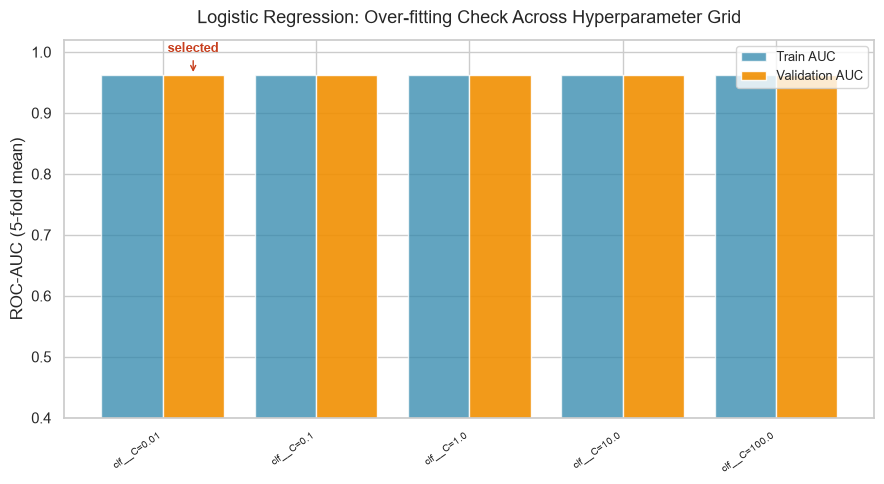

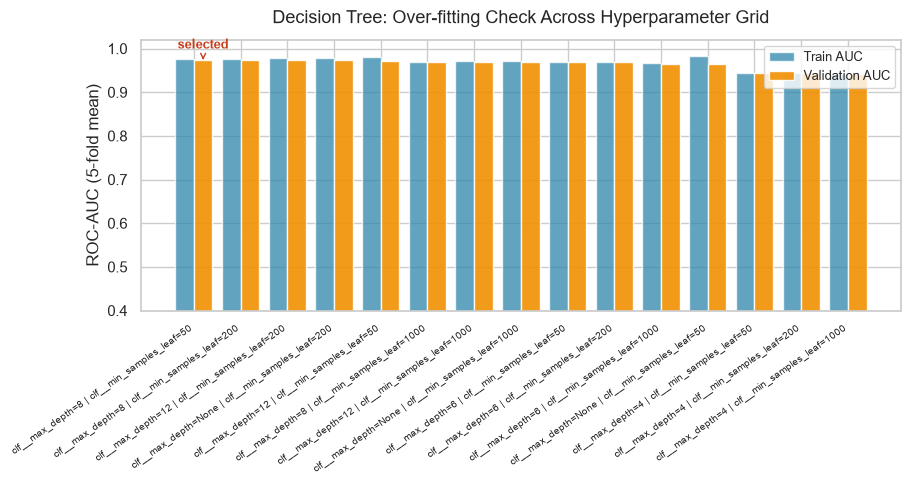

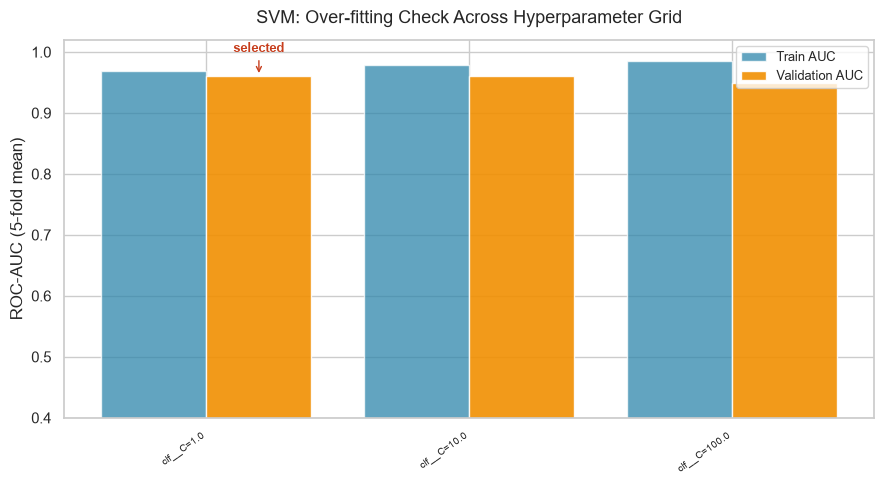

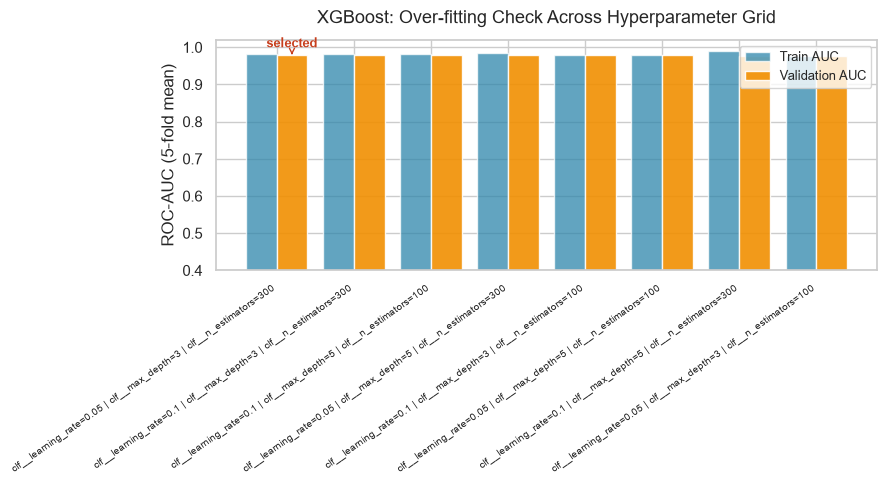

In [24]:
for name, filename in [
    ("Logistic Regression", "cv_logistic.png"),
    ("Decision Tree", "cv_decision.png"),
    ("SVM", "cv_svm.png"),
    ("XGBoost", "cv_xgboost.png"),
]:
    plots.plot_cv_results(fitted[name].cv_results, name, filename)

Each chart plots training AUC against validation AUC for every point in the grid.
Where the training bar sits far above the validation bar, that configuration is
over-fitting; the selected point is annotated.

## 6. Performance metrics / confusion matrix

All four models are evaluated on the held-out test set (14,422 patients, 1,272
positive), which was never used for fitting or tuning.

In [25]:
evals = [baseline_evaluation("Majority Baseline", splits.y_test)]
for name, model in fitted.items():
    evals.append(evaluate_pipeline(name, model.best_estimator,
                                   splits.X_test, splits.y_test))

table = metrics_table(evals)
table

,ROC-AUC,PR-AUC,Accuracy,Precision,Recall,F1-Score,TP,FP,TN,FN
Model,,,,,,,,,,
Majority Baseline,NaN,0.0882,0.9118,0.0000,0.0000,0.0000,0,0,13150,1272
Logistic Regression,0.9639,0.8314,0.8878,0.4336,0.8876,0.5826,1129,1475,11675,143
Decision Tree,0.9748,0.8647,0.8807,0.4204,0.9316,0.5793,1185,1634,11516,87
SVM,0.9619,0.7822,0.8960,0.4548,0.9009,0.6044,1146,1374,11776,126
XGBoost,0.9799,0.8923,0.9034,0.4756,0.9277,0.6288,1180,1301,11849,92


The confusion counts are carried in the same table: TP, FP, TN, FN per model.

**Every model's accuracy is below the 0.9118 baseline, and that is the correct
result, not a failure.** Class weighting buys recall at the cost of accuracy:
XGBoost accepts 1,301 false positives to catch 1,180 of the 1,272 diabetic patients.
The baseline takes the opposite trade and catches none.

For screening the asymmetry is the point. A false positive costs a blood test; a
false negative lets a treatable disease go uncaught.

(<Axes: title={'center': 'Model Comparison on the Test Set'}, ylabel='Score'>,
 WindowsPath('P:/My projects/ML lab project/figures/09_metric_comparison.png'))

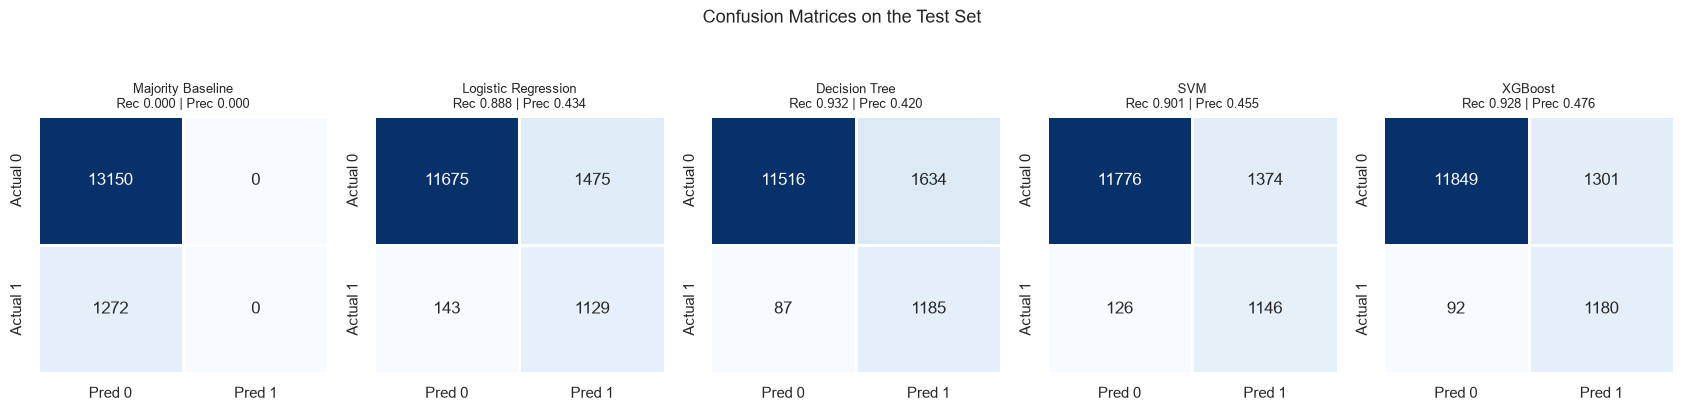

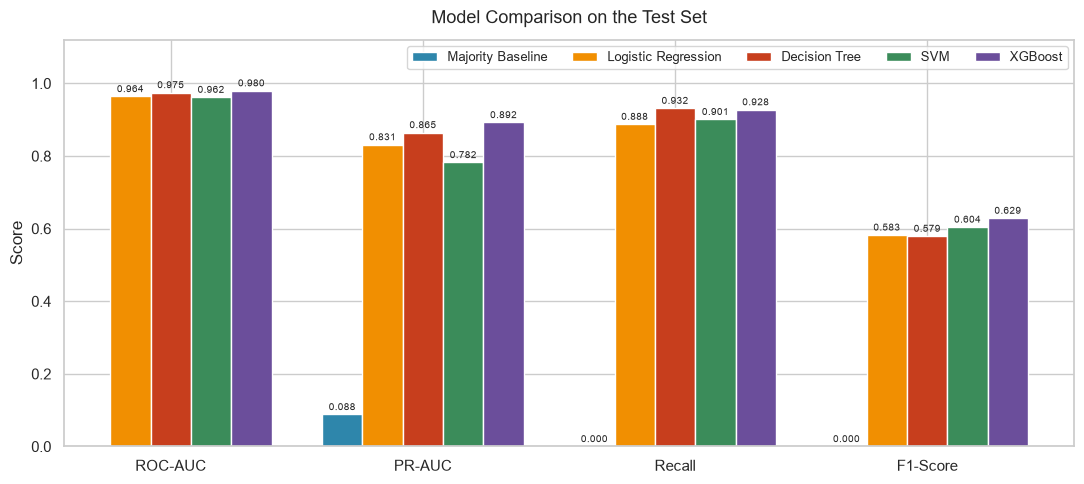

In [26]:
plots.plot_confusion_matrices(evals)
plots.plot_metric_comparison(table)

### ROC curve

All four models on one overlaid chart, as required by the brief.

(<Axes: title={'center': 'ROC Curves -- All Models on the Test Set'}, xlabel='False Positive Rate (1 - Specificity)', ylabel='True Positive Rate (Sensitivity)'>,
 WindowsPath('P:/My projects/ML lab project/figures/06_roc_curves.png'))

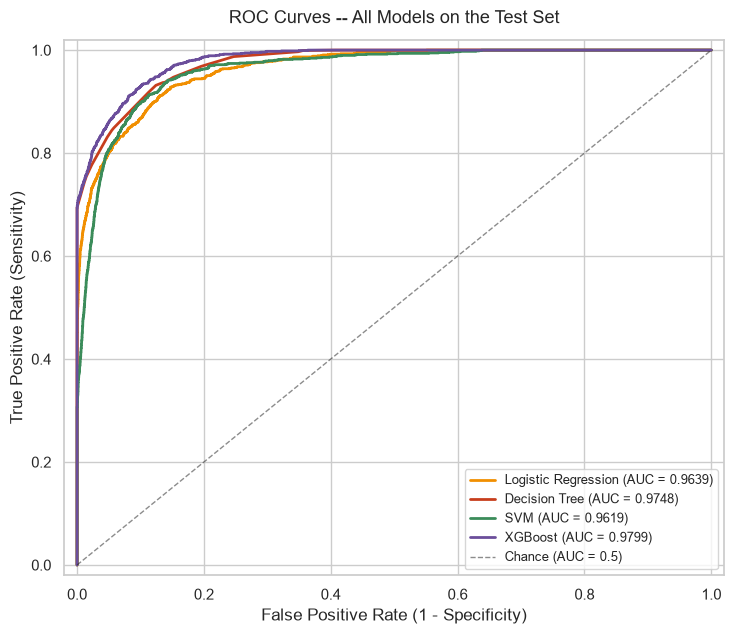

In [27]:
plots.plot_roc_curves(evals)

### Precision-Recall curve

Included alongside the ROC curve because at an 8.8% positive rate it is the more
informative view. The no-skill reference is the positive rate itself (0.0882). SVM
is the clearest illustration of why: a competitive ROC-AUC of 0.9619 but the weakest
PR-AUC of 0.7822, the classic symptom of scores that are poorly ordered in the
region that matters.

(<Axes: title={'center': 'Precision-Recall Curves -- the right view for an 8.8% positive class'}, xlabel='Recall (Sensitivity)', ylabel='Precision (Positive Predictive Value)'>,
 WindowsPath('P:/My projects/ML lab project/figures/07_precision_recall_curves.png'))

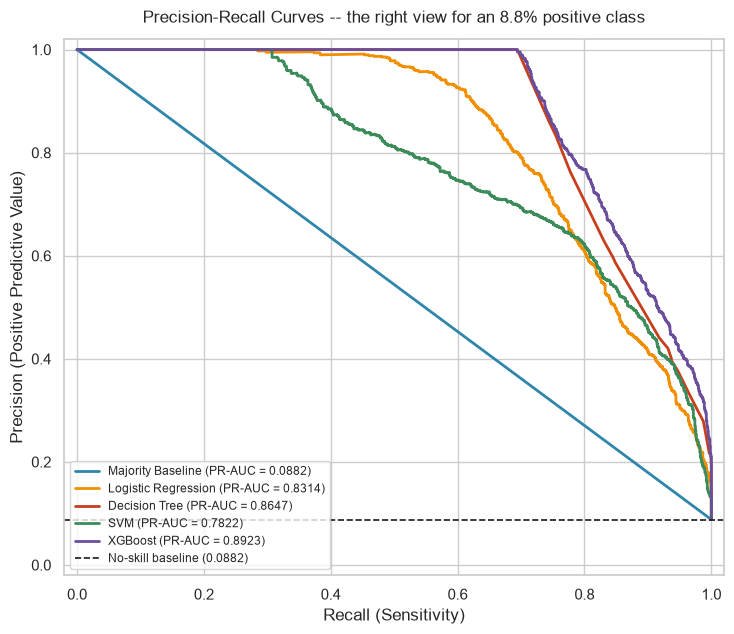

In [28]:
plots.plot_pr_curves(evals, float(splits.y_test.mean()))

## 7. Result

### 7.1 Final comparison table

The table below is in the format required by the brief: columns **1. Model list,
2. AUC, 3. Accuracy, 4. Precision, 5. Recall, 6. F1-Score**, with rows
**Log St, DT, SVM, XGBoost**.

In [29]:
result = final_result_table(evals)
result

,2. AUC,3. Accuracy,4. Precision,5. Recall,6. F1-Score
1. Model list,,,,,
Log St,0.9639,0.8878,0.4336,0.8876,0.5826
DT,0.9748,0.8807,0.4204,0.9316,0.5793
SVM,0.9619,0.8960,0.4548,0.9009,0.6044
XGBoost,0.9799,0.9034,0.4756,0.9277,0.6288


The majority-class baseline is shown as a reference line rather than a fifth row, so
the table keeps exactly the four models the brief specifies:

In [30]:
print(baseline_reference_line(evals))

Majority-class baseline (always predict 'no diabetes'): Accuracy 0.9118, Recall 0.0000, PR-AUC 0.0882


### 7.2 Which model performed best?

**XGBoost is best on AUC (0.9799), F1 (0.6288), precision (0.4756) and tied on
recall.** The Decision Tree has the highest raw recall (0.9316) but the lowest
precision (0.4204), so it buys its extra true positives with more false alarms.

### 7.3 Which model was most interpretable, and was XGBoost worth it?

This is the tradeoff the brief asks us to address explicitly.

| Model | AUC | What a clinician gets |
|---|---|---|
| Log St | 0.9639 | One coefficient per feature, directly readable as risk factors |
| DT | 0.9748 | A small set of if/then rules that mirror clinical reasoning |
| XGBoost | **0.9799** | 300 boosted trees; importance scores, but no single readable rule |

**XGBoost's AUC advantage over the Decision Tree is 0.0051.** For a clinical
decision-support tool that is a poor trade: you would surrender a rule set a doctor
can audit line by line in exchange for half a point of AUC, on a synthetic dataset
whose real-world performance is unknown anyway.

**Recommendation: deploy the Decision Tree (or Logistic Regression), and report
XGBoost only as the performance ceiling.** The Decision Tree is the stronger of the
two interpretable options - it beats logistic regression by 0.0109 AUC and its rules
are easier to walk a clinician through. The honest summary is that model complexity
is not rewarded in this problem, because the signal is concentrated in two lab
measurements.

### 7.4 Feature importance

One-hot encoding turns `smoking_history` into six columns, which would dominate any
chart. Columns are summed back into their parent feature, so both models are
reported on the same eight features.

,Feature,LogReg,Feature,Tree
0,HbA1c_level,0.3241,HbA1c_level,0.4945
1,blood_glucose_level,0.1871,blood_glucose_level,0.3530
2,age,0.1649,age,0.1166
3,smoking_history,0.1267,bmi,0.0316
4,bmi,0.0933,hypertension,0.0044
5,gender,0.0492,gender,0.0000
6,hypertension,0.0312,heart_disease,0.0000
7,heart_disease,0.0234,smoking_history,0.0000


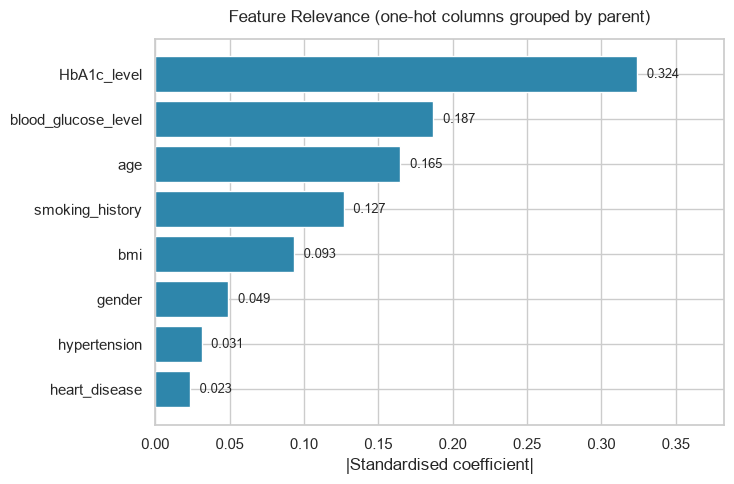

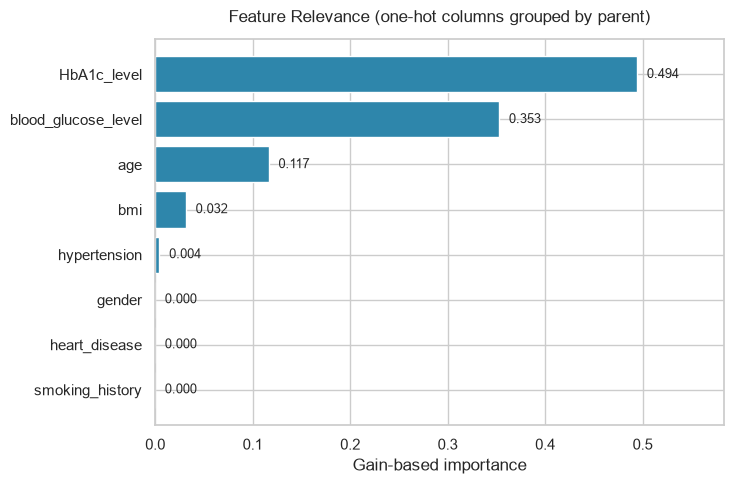

In [31]:
imp_logreg = feature_importance(fitted["Logistic Regression"])
imp_tree = feature_importance(fitted["Decision Tree"])
plots.plot_feature_importance(
    imp_logreg, imp_logreg["Measure"].iloc[0],
    "10_feature_importance_logistic_regression.png")
plots.plot_feature_importance(
    imp_tree, imp_tree["Measure"].iloc[0],
    "11_feature_importance_decision_tree.png")

pd.concat([
    imp_logreg[["Feature", "Importance"]].rename(columns={"Importance": "LogReg"}),
    imp_tree[["Feature", "Importance"]].rename(columns={"Importance": "Tree"}),
], axis=1).round(4)

Both models agree on the top three - `HbA1c_level`, `blood_glucose_level`, `age` -
which is reassuring, since they measure the condition by completely different means.
`age` deserves a caveat: all 17,219 patients under 18 contribute only 82 positives,
so in this dataset being a child is nearly equivalent to being negative.

They disagree at the bottom. The tree gives near-zero importance to `gender`,
`heart_disease` and `smoking_history` because greedy splits never need them once
`HbA1c` and `glucose` are available, whereas Logistic Regression retains
`smoking_history` at 0.127 as additive evidence. A tree's zero means "not used for
splitting", not "no association".

## 8. Conclusions and limitations

### 8.1 What the exercise showed

- **Accuracy alone is actively misleading under imbalance.** The majority-class
  baseline scores 0.9118 and catches nothing; the best model scores 0.9034 and
  catches 92.8% of cases.
- **Precision-Recall curves beat ROC curves** for a rare positive class, which is
  why SVM looks acceptable on ROC-AUC (0.9619) and weak on PR-AUC (0.7822).
- **Regularisation is measurable.** An unrestricted tree loses 0.1488 ROC-AUC to
  over-fitting; tuning recovers it.
- **`"No Info"` is a category, not a blank.** Its 4.06% diabetes rate against
  9.53-17.00% for real smoking categories makes imputing it actively misleading.
- **Model complexity was not rewarded.** The RBF kernel performed *worse* than
  logistic regression, and XGBoost's AUC gain over a single decision tree was only
  0.0051 - which is why the interpretable model is the recommended one.

### 8.2 Limitations

- **The data is synthetic.** There is no institutional citation, and the generator
  produced 17,219 patients under 18 with a minimum age of 0.08 years, including 911
  infants under 1 year old. No clinical claim can be supported by this dataset.
- **No external validation.** A single 70/15/15 split on one dataset, with no
  cross-dataset or temporal check.
- **The operating threshold was never chosen.** `predict` uses the default 0.5. A
  real screening tool would tune the threshold on the validation split to hit a
  target recall, and that step is not implemented.
- **Cost asymmetry is asserted, not modelled.** That a missed diagnosis is worse than
  a false alarm is a clinical assumption; no cost matrix is applied.
- **SVM fitted on a subsample.** It was tuned and refit on a stratified 20,000-row
  subsample rather than all 67,302 training rows, so its hyperparameters and its
  0.9619 AUC are a weaker estimate than the other three models. Fitting it on the
  full split was avoided only because an RBF fit is roughly quadratic in sample
  count.

### 8.3 Deviations from the approved project plan

Recorded explicitly, because the plan is part of the submission.

1. **Implausible values were documented, not zeroed to missing.** The plan proposed
   treating biologically impossible values as missing data. They were instead
   reported and left in place. A minimum age of 0.08 years and 911 infants under one
   year old indicate a synthetic generator rather than corrupted records, so blanking
   them would have discarded 17% of the rows without fixing anything real. The
   consequence is stated in 8.2: no clinical claim can be supported.
2. **No second-dataset validation.** The plan offered this as optional. The two
   candidate datasets share only three usable features, so an external test would
   have been weak evidence; the limitation is recorded instead.
3. **Dataset changed from Pima to Kaggle.** Directed after the plan was written. Note
   that the plan assumed roughly 65/35 class balance; the actual dataset is 91.5/8.5,
   considerably worse, which is why a majority-class baseline and PR curves were
   added beyond the plan's scope.
4. **Added beyond the plan:** majority-class baseline, PR-AUC and PR curves,
   boxplots, and explicit documentation of the `"No Info"` sentinel - all required
   by the severity of the imbalance.

## Appendix: reproducibility

- `random_state = 42` for splitting, cross-validation, and every model.
- `python run_pipeline.py` reproduces every number and figure in this notebook.
- Figures are written to `figures/`, tables to `results/`.
- `results/final_result_table.csv` holds the section 7 table in the brief's format.